# Бинарная классификация, логистическая регрессия

# 🍷 Классифицируем ирисы и вино

#### На этом семинаре мы:
1. Рассмотрим задачу бинарной классификации на двух разных датасетах
2. Обсудим, когда какие метрики качества стоит использовать
3. Подберем коэффициент регуляризации с помощью кросс-валидации
4. Нарисуем ROC-кривую и посчитаем площадь под ней
---

## Чуть-чуть формул

Мы решаем задачу бинарной классификации, в которой целевая переменная $y$ принимает два значения: -1 и 1. Эту задачу можно решить при помощи линейного классификатора

$$
f(x_i, w) = \mathrm{sign}\left(\langle x_i, w \rangle\right).
$$

Функция потерь для такой задачи – это сумма индикаторов того, что предсказание сделано неверно:

$$Q(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}[y_i \ne \mathrm{sign}\left(\langle x_i, w \rangle\right)].$$


Логистическая регрессия предлагает использовать логистическую функцию потерь:

$$
Q'(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}\log(1 + e^{-y_i \langle x_i, w \rangle}) \rightarrow \min_w.
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Классификация ирисов

### Загрузка данных

Рассмотрим свойства логистической регрессии на примере классического набора данных ["Ирисы Фишера"](https://ru.wikipedia.org/wiki/Ирисы_Фишера). Этот набор состоит из 150 наблюдений, каждое из которых представляет собой четыре измерения: длина наружной доли околоцветника (`sepal length`), ширина наружной доли околоцветника (`sepal width`), длина внутренней доли околоцветника (`petal length`), ширина внутренней доли околоцветника (`petal width`). Каждое наблюдение относится к одному из трех классов ириса: `setosa`, `versicolor` или `virginica`. Задача состоит в том, чтобы по измерениям предсказать класс цветка.

В sklearn есть некоторое количество учебных датасетов, включая датасет с ирисами. Загрузим данные оттуда и сразу выделим целевую переменную

In [2]:
from sklearn.datasets import load_iris
data = load_iris()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target']
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Благодаря тому, что загрузили учебный датасет из sklearn, можем легко и удобно вывести информацию о нем одной командой

In [3]:
print(load_iris().DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Перекодирование целевой переменной

На датасете по ирисам можно решать задачу многоклассовой классификации, но в этом ноутбуке мы легким движением руки сделаем задачу бинарной: будем предсказывать принадлежность цветка к виду `virginica` против принадлежности ко всем прочим видам.

Для этого перекодируем целевую переменную так, чтобы цветки вида `virginica` имели метку 1, а прочих видов – метку -1.

Сейчас вектор целевой переменной выглядит так

In [4]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

У нас есть три класса ирисов, можем посмотреть их названия. Наш целевой класс `virginica` сейчас закодирован цифрой 2

In [5]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

И перекодируем целевую переменную

In [6]:
y = np.where(y == 2, 1, -1)

Проверим результат

In [7]:
y

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

### Обработка признаков

В этом ноутбуке мы сконцентрируемся непосредственно на задаче классификации и пропустим этап EDA. Волевым решением оставим только два признака: `petal length (cm)` и `petal width (cm)`. С двумя признаками решающую границу модели можно нарисовать на плоскости.
Отделим их в отдельную матрицу, разделим выборку на обучающую и тестовую.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 123

In [9]:
X = X[['petal length (cm)', 'petal width (cm)']]
# stratify=y сохраняет доли классов одинаковыми в обучающей и тестовой выборках
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=RANDOM_STATE, stratify=y)

Отмасштабируем выборки при помощи StandardScaler

In [10]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

**Вопрос:** Почему для обучающей выборки мы вызываем `fit_transform`, а для тестовой — только `transform`?

Выведем диаграмму рассеяния для признаков

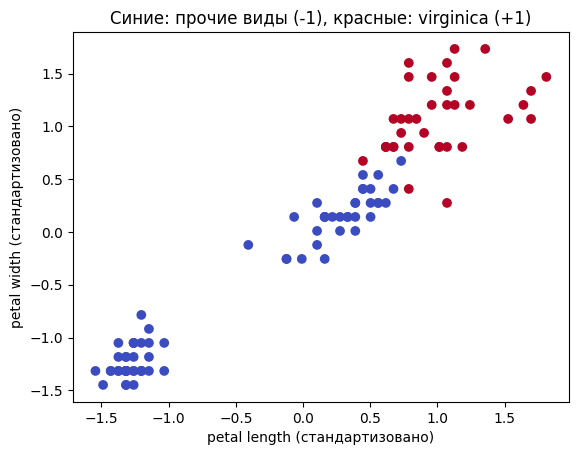

In [11]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm')
plt.xlabel('petal length (стандартизовано)')
plt.ylabel('petal width (стандартизовано)')
plt.title('Синие: прочие виды (-1), красные: virginica (+1)');

**Вопрос:** О чем нам говорит полученная диаграмма?

### Обучение модели

Обучим логистическую регрессию на тренировочной выборке.

In [12]:
from sklearn.linear_model import LogisticRegression

In [50]:
lr = LogisticRegression()

lr.fit(X_train, y_train)


LogisticRegression()

### Метрика качества

Для задачи классификации используются:

- Accuracy (доля правильных ответов)
- Precision (точность)
- Recall (полнота)
- F-мера (метрика, сочетающая точность и полноту)

**Вопрос:** Как выбрать метрику?

Посмотрим на распределение классов

In [14]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

-1    70
 1    35
Name: count, dtype: int64
-1    30
 1    15
Name: count, dtype: int64


**Вопрос:** Подходит ли Accuracy? А F-мера?

In [15]:
from sklearn.metrics import f1_score
print('F1-мера: ', f1_score(y_test, lr.predict(X_test)))

F1-мера:  0.9333333333333333


Построим решающую поверхность для нашего классификатора

In [16]:
# !pip install mlxtend  # раскомментируйте, если библиотека не установлена

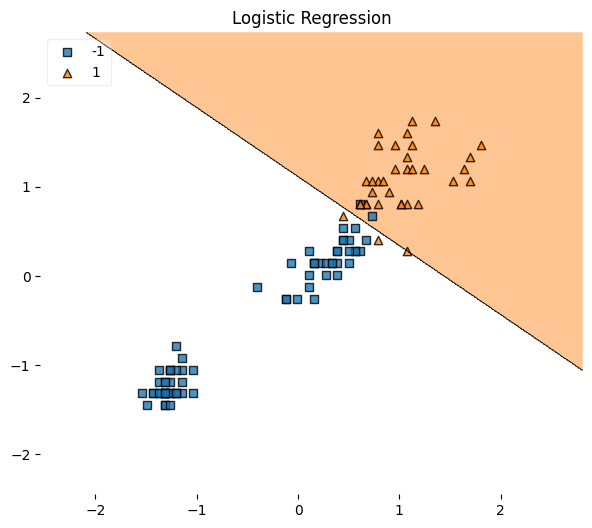

In [17]:
from mlxtend.plotting import plot_decision_regions

fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_regions(X=X_train, y=np.array(y_train), clf=lr, legend=2, ax=ax)
ax.set_title('Logistic Regression')
plt.show()

### Влияние коэффициента регуляризации

Обучим три различные логистические регрессии с разным параметром регуляризации $\alpha$ (обратите внимание, что в реализации `sklearn` $C = 1/\alpha$)

In [18]:
C = [0.01, 0.05, 10]
lr1 = LogisticRegression(C=C[0])
lr2 = LogisticRegression(C=C[1])
lr3 = LogisticRegression(C=C[2])

Посмотрим, как изменяется разделяющая поверхность в зависимости от $\alpha$

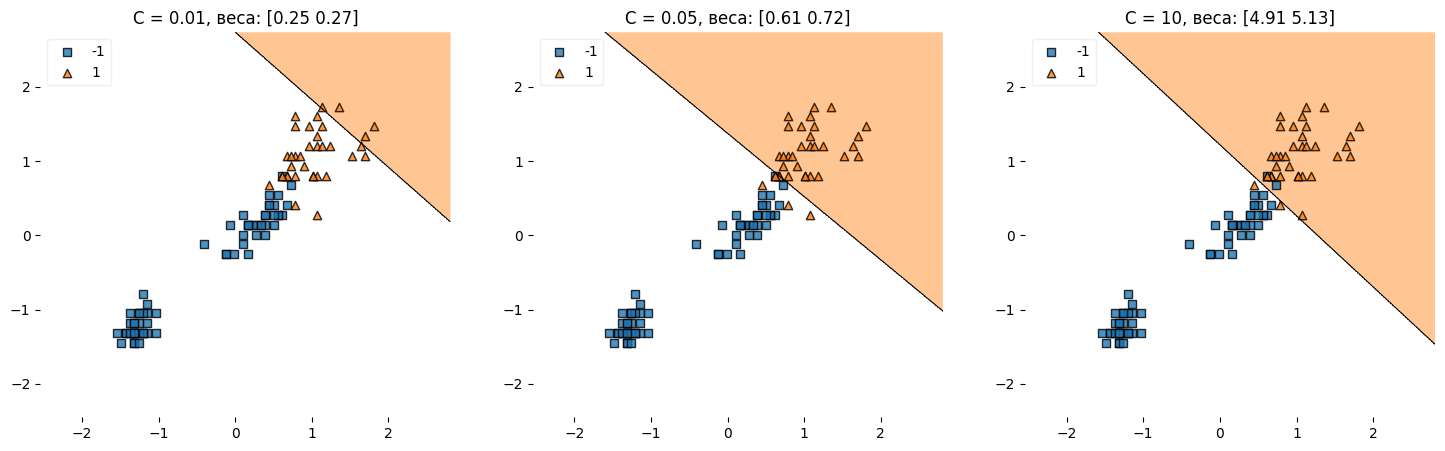

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['C = 0.01', 'C = 0.05', 'C = 10']
for clf, lab, ax in zip([lr1, lr2, lr3], labels, axes):
    clf.fit(X_train, y_train)  # обучаем модель прямо здесь
    plot_decision_regions(X=X_train, y=np.array(y_train), clf=clf, legend=2, ax=ax)
    ax.set_title(f'{lab}, веса: {np.round(clf.coef_[0], 2)}')

plt.show()

Сравним качество моделей с разной силой регуляризации на тестовой выборке.

**Вопрос:** Какие метрики сильно меняются при изменении `C`, а какие почти нет? Почему?

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rows = []
for name, clf in [('C = 0.01', lr1), ('C = 0.05', lr2), ('C = 1 (по умолчанию)', lr), ('C = 10', lr3)]:
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]
    rows.append({
        'модель': name,
        'доля предсказанных +1': (pred == 1).mean(),
        'accuracy': accuracy_score(y_test, pred),
        # zero_division=0: если модель ни разу не предсказала +1, precision не определена
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC AUC': roc_auc_score(y_test, proba),
    })

pd.DataFrame(rows).set_index('модель').round(3)

,доля предсказанных +1,accuracy,precision,recall,F1,ROC AUC
модель,,,,,,
C = 0.01,0.022,0.689,1.000,0.067,0.125,0.998
C = 0.05,0.311,0.978,1.000,0.933,0.966,0.998
C = 1 (по умолчанию),0.333,0.956,0.933,0.933,0.933,0.998
C = 10,0.333,0.956,0.933,0.933,0.933,0.998


### Выводы

1. **Accuracy обманывает.** При C = 0.01 модель нашла только 1 virginica из 15, но accuracy у нее 0.69. Модель, которая всегда отвечает «не virginica», получила бы 0.67. Поэтому при дисбалансе классов нельзя смотреть только на accuracy.

2. **Сильная регуляризация делает модель неуверенной.** Чем меньше C, тем меньше веса. Вероятности у всех цветков становятся близкими друг к другу и почти не дотягивают до 0.5. Модель почти никого не относит к классу +1, поэтому граница на графике сдвигается вправо вверх.

3. **ROC AUC от этого не страдает.** ROC AUC оценивает модель сразу при всех порогах, а F1 — при одном пороге 0.5. Регуляризация сдвинула все вероятности вниз, поэтому порог 0.5 стал неудачным, но при подходящем пороге модель работала бы так же хорошо, как без регуляризации..

4. **Слишком слабая регуляризация тоже ничего не дает.** C = 1 и C = 10 показывают одинаковый результат. Лучшее значение C нужно подбирать на кросс-валидации, это мы сделаем на вине.

**Упражнение.** Замените целевой класс на `versicolor` (в исходной разметке это метка 1) и повторите обучение. Что произойдет с качеством и почему?

## Классификация вина

---



### Загружаем данные

Мы будем работать с [набором данных](https://www.kaggle.com/piyushgoyal443/red-wine-dataset?select=wineQualityReds.csv), содержащим физико-химические характеристики красного вина. Качество каждого вина оценено экспертами по шкале от 0 до 10, в данных встречаются оценки от 3 до 8. Исходно это задача предсказания оценки качества, но мы сведем ее к бинарной классификации.

In [21]:
RED_WINE = 'https://github.com/evgpat/ml_basics_course/raw/main/datasets/wineQualityReds.csv'

data = pd.read_csv(RED_WINE)

data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


**Итог:** в датасете 1599 вин и 12 столбцов: 11 физико-химических признаков (кислотность, сахар, сульфаты, алкоголь и другие) и оценка качества `quality`. Все признаки числовые, кодировать ничего не нужно.

Посмотрим, какого качества вино есть в датасете

In [22]:
data['quality'].unique()

array([5, 6, 7, 4, 8, 3])

**Итог:** встречаются только оценки от 3 до 8. Совсем плохих (0–2) и отличных (9–10) вин в данных нет.

Убедимся, что нет пропусков

In [23]:
data.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


**Итог:** пропусков нет, заполнять или удалять ничего не нужно. Все признаки непрерывные, целевая переменная `quality` дискретная.

Проверим, нет ли в данных полных дубликатов строк

In [24]:
data.duplicated().sum()

np.int64(240)

**Итог:** 240 строк (15%) полностью повторяют другие строки. Скорее всего, одно и то же вино попало в данные несколько раз.

Чем это опасно: при случайном разбиении копия может оказаться и в обучающей, и в тестовой выборке. Тогда модель проверяется на объектах, которые уже видела, и оценка качества на тесте получается завышенной.

Удалим дубликаты.

In [25]:
data = data.drop_duplicates().reset_index(drop=True)
data.shape

(1359, 12)

**Итог:** осталось 1359 уникальных вин. Дальше работаем с ними.

In [26]:
data['quality'].value_counts(normalize=True)

,proportion
quality,
5,0.424577
6,0.393672
7,0.122884
4,0.038999
8,0.012509
3,0.007358


**Итог:** почти все вина получили 5 или 6 (вместе 82%). Оценки 3, 4 и 8 встречаются редко, в сумме около 6%. Предсказывать каждую оценку отдельно было бы трудно: для редких оценок слишком мало примеров. Это еще одна причина перейти к бинарной задаче.

### Перекодирование целевой переменной

Снова перейдем к задаче бинарной классификации: будем отличать **хорошее вино** (оценка 6 и выше) от всего остального.

Закодируем столбец `quality` так, чтобы вина с оценкой не ниже 6 получили метку 1, а все прочие – метку -1.

In [27]:
qual = pd.Series(np.where(data['quality'] >= 6, 1, -1), index=data.index, name='quality')

Сразу проверим баланс классов

In [28]:
qual.value_counts()

,count
quality,
1,719
-1,640


In [29]:
qual.value_counts(normalize=True)

,proportion
quality,
1,0.529065
-1,0.470935


**Итог:** классы почти сбалансированы: 53% хороших вин и 47% остальных. Модель, которая всегда отвечает «вино хорошее», получила бы F1 около 0.69. Это нижняя планка: наша модель должна быть лучше нее.

**Отступление про константную модель.** Константная модель называет хорошими все вина. Посчитаем ее precision и recall.

- Все хорошие вина она находит, значит, полнота максимальная:
$$\text{recall} = \frac{TP}{TP + FN} = 1.$$
- Среди вин, которые она назвала хорошими (а это все вина), хороших столько, какова их доля в выборке. Обозначим эту долю $p$:
$$\text{precision} = \frac{TP}{TP + FP} = p.$$

Подставим в формулу F1:

$$F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}} = \frac{2 \cdot p \cdot 1}{p + 1} = \frac{2p}{1 + p}.$$

У нас доля хороших вин $p \approx 0.53$, поэтому

$$F_1 = \frac{2 \cdot 0.53}{1 + 0.53} \approx 0.69.$$

In [51]:
from sklearn.metrics import f1_score
f1_score(y_test, np.ones(len(y_test)))

0.6923076923076923

### Обработка признаков

Разделим признаки и целевую переменную, выборку - на тренировочную и тестовую, при помощи `StandardScaler` отмасштабируем данные

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(data.drop('quality', axis=1), qual, test_size=0.3,
                                                    random_state=RANDOM_STATE, stratify=qual)

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

**Итог:** в обучающей выборке 951 вино, в тестовой 408, доля хороших вин в обеих одинаковая (благодаря `stratify`). Скейлер обучаем только на обучающей выборке

И посмотрим на диаграмму.

**Вопрос:** В чем отличие от предыдущего датасета?

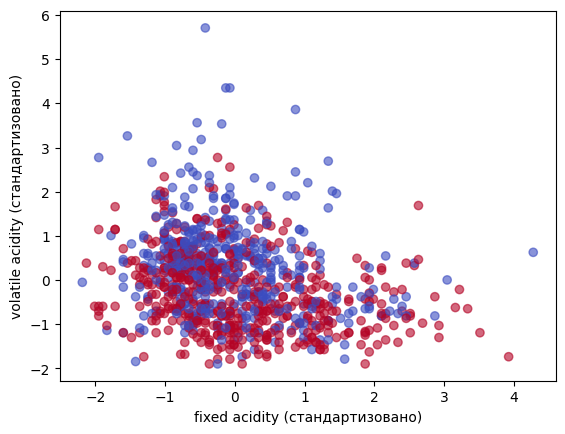

In [31]:
feature_names = data.drop('quality', axis=1).columns
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', alpha=0.6)
plt.xlabel(f'{feature_names[0]} (стандартизовано)')
plt.ylabel(f'{feature_names[1]} (стандартизовано)');

**Итог:** в отличие от ирисов, классы сильно перемешаны, и по двум признакам хорошее вино от остального не отделить. У хороших вин в среднем немного ниже летучая кислотность (volatile acidity), но разброс большой. Модели понадобятся все 11 признаков сразу, и идеального качества ждать не стоит.

### Подбор коэффициента регуляризации с помощью кросс-валидации

При помощи кросс-валидации подберем оптимальное значение коэффициента регуляризации для логистической регрессии и обучим модель с этим параметром.

Значения `C` перебираем по **логарифмической сетке**: от 0.001 до 100. Параметр регуляризации меняет поведение модели в разы, а не на единицы, поэтому шаг по сетке тоже должен быть мультипликативным.

Качество на кросс-валидации будем измерять по **ROC AUC**: эта метрика не зависит от порога. Почему это важно именно при подборе `C`, обсудим после графика. Подробно ROC AUC разберем в конце ноутбука.

In [32]:
from sklearn.model_selection import cross_validate

C_values = np.logspace(-3, 2, 20)  # 20 значений от 10^-3 до 10^2
scores_lr = []

for c in C_values:
    lr = LogisticRegression(C=c)

    cv_lr = cross_validate(lr, X_train, y_train, cv=5, scoring='roc_auc')['test_score']

    scores_lr.append(cv_lr.mean())

Выведем значения метрики качества для каждого `C`

In [33]:
pd.Series(scores_lr, index=np.round(C_values, 4), name='ROC AUC на кросс-валидации')

,ROC AUC на кросс-валидации
0.0010,0.802215
0.0018,0.803922
0.0034,0.805180
0.0062,0.806733
0.0113,0.807413
0.0207,0.808804
0.0379,0.809709
0.0695,0.809818
0.1274,0.809724
0.2336,0.809592


In [34]:
max(scores_lr)

np.float64(0.8098176734527385)

In [35]:
np.argmax(scores_lr)

np.int64(7)

In [36]:
best_C = C_values[np.argmax(scores_lr)]
best_C

np.float64(0.06951927961775606)

**Итог:** лучший ROC AUC на кросс-валидации равен 0.810 при C ≈ 0.07. Это значение не на краю сетки, значит, расширять сетку не нужно.

Нарисуем зависимость качества от `C`. Ось X логарифмическая.

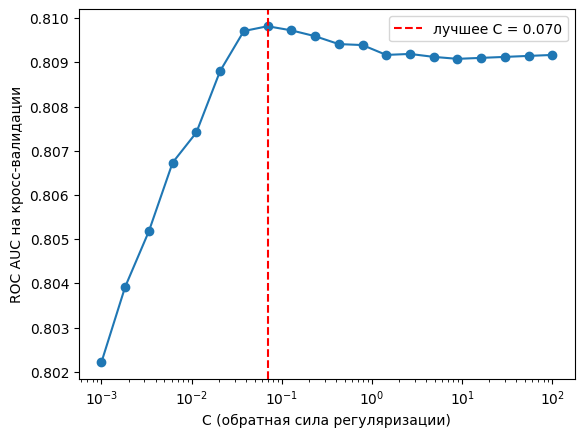

In [37]:
plt.semilogx(C_values, scores_lr, marker='o')
plt.axvline(best_C, linestyle='--', c='red', label=f'лучшее C = {best_C:.3f}')
plt.xlabel('C (обратная сила регуляризации)')
plt.ylabel('ROC AUC на кросс-валидации')
plt.legend();

**Важно:** если лучшее значение оказалось на краю сетки, сетку нужно расширить в ту сторону. Оптимум может лежать за ее пределами, и вывод «это лучший `C`» тогда неверен.

**Вопрос:** Почему кривая почти плоская? О чем это говорит?

**Итог:** ROC AUC меняется всего от 0.802 до 0.810, то есть меньше чем на одну сотую. Признаков всего 11, а объектов почти тысяча, поэтому модели почти не на чем переобучиться, и регуляризация мало на что влияет. В задачах с большим числом признаков подбор C может улучшить качество заметно.

**Почему не F1?** Если подбирать C по F1, лучшим окажется C = 0.001, самое левое значение сетки. Это ловушка. При сильной регуляризации вероятности всех вин стягиваются к доле хороших вин (53%), то есть чуть выше порога 0.5. Модель начинает чаще называть вино хорошим: recall растет, precision падает, а F1 в сумме растет, хотя упорядочивает вина модель хуже. На ирисах был тот же эффект, только там доля класса +1 была меньше 0.5, и модель переставала находить virginica. ROC AUC от порога не зависит, поэтому в эту ловушку не попадает.

И обучим модель с наилучшим параметром регуляризации

In [38]:
lr = LogisticRegression(C=best_C)

lr.fit(X_train, y_train)

print(f1_score(y_test, lr.predict(X_test)))

0.7713625866050808


**Вопрос:** Насколько хороша модель? Что можно сделать, чтобы ее улучшить?

**Итог:** на тесте F1 = 0.771. Константная модель дала бы F1 около 0.69: наша модель лучше, но ненамного. ROC AUC на тесте посчитаем ниже и сравним с результатом на кросс-валидации.

### ROC-кривая

Рассмотрим внимательно метрику ROC AUC.

Для начала вспомним, что мы работаем с матрицей ошибок:

|       | alg = 1          | alg = -1    |
|-------| -----------------|-------------|
|y = 1  |TP                |FN           |
|y = -1 |FP                | TN          |

Определим следующие величины:

$$
TPR \text{ (true positive rate, recall, sensitivity)} = \dfrac{TP}{TP + FN} –
$$
доля правильно предсказанных объектов положительного класса.

$$
FPR \text{ (false positive rate, 1 - specificity)} = \dfrac{FP}{FP + TN} –
$$
доля неправильно предсказанных объектов отрицательного класса.

Рассмотрим задачу мягкой классификации: мы предсказываем вероятности принадлежности наблюдения к положительному и отрицательному классам. Тогда TPR и FPR будут зависеть от порога для вероятности, выше которого наблюдение будет отнесено к положительному классу. ROC-кривая строится в координатах $(FPR, TPR)$ и показывает комбинации TPR и FPR при всевозможных значениях порога.

Для хорошего классификатора кривая лежит выше диагонали и выгнута к левому верхнему углу, а для идеального классификатора она будет проходить через точку $(0, 1)$ (почему?).

[<img src="https://upload.wikimedia.org/wikipedia/commons/6/6b/Roccurves.png" alt="drawing" width="350"/>](https://ru.wikipedia.org/wiki/ROC-кривая)




Построим ROC-кривую для следующей выборки

In [39]:
# Истинные метки
y = [-1, 1, 1, -1, 1, 1]
# Предсказанные оценки (уверенность модели в классе +1), а не метки
p = [0.5, 0.1, 0.2, 0.9, 0.7, 0.1]

Упорядочим наблюдения по убыванию ответов алгоритма.

In [40]:
y = [-1, 1, -1, 1, 1, 1]
p = [0.9, 0.7, 0.5, 0.2, 0.1, 0.1]

Разобьем единичный квадрат на $m$ частей по вертикали и $n$ частей по горизонтали, где $m$ – число объектов с меткой 1 в $y$, $n$ – число объектов с меткой -1. Стартуем из точки $(0, 0)$. Если значение $y$ равно 1, делаем шаг вверх, а если -1 – вправо. Понятно, что конечная точка нашего маршрута – точка $(1, 1)$.


**Важный момент:** если у нескольких объектов значения предсказаний равны, а $y$ – различны, то мы должны сделать ход "по диагонали".


In [41]:
from sklearn.metrics import roc_curve, auc

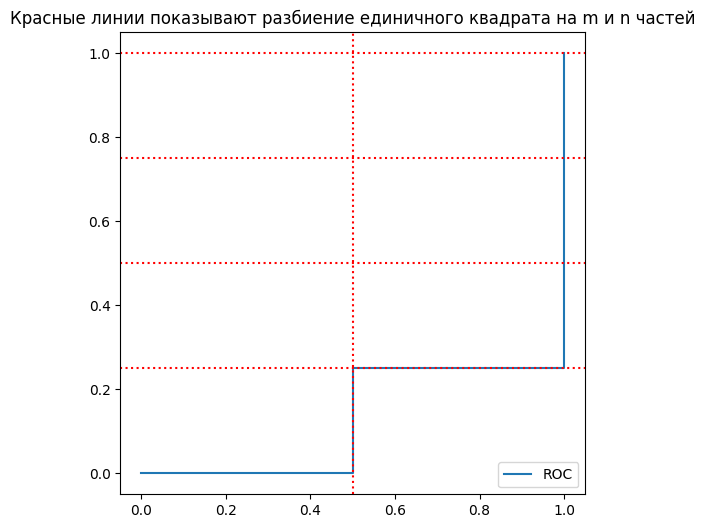

In [42]:
fpr, tpr, _ = roc_curve(y, p)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC")
plt.axvline(0.5, linestyle="dotted", c="red")
plt.axhline(0.25, linestyle="dotted", c="red")
plt.axhline(0.5, linestyle="dotted", c="red")
plt.axhline(0.75, linestyle="dotted", c="red")
plt.axhline(1.0, linestyle="dotted", c="red")
plt.title("Красные линии показывают разбиение единичного квадрата на m и n частей")
plt.legend();

Полученная кривая и является ROC-кривой.

**(Почему этот алгоритм имеет смысл?)**

**Пример с диагональным шагом**


Сформируем другие данные

In [43]:
p = [0.5, 0.1, 0.2, 0.6, 0.2, 0.3, 0.0]
y = [-1, -1, -1, 1, 1, 1, -1]

In [44]:
fpr, tpr, _ = roc_curve(y, p)

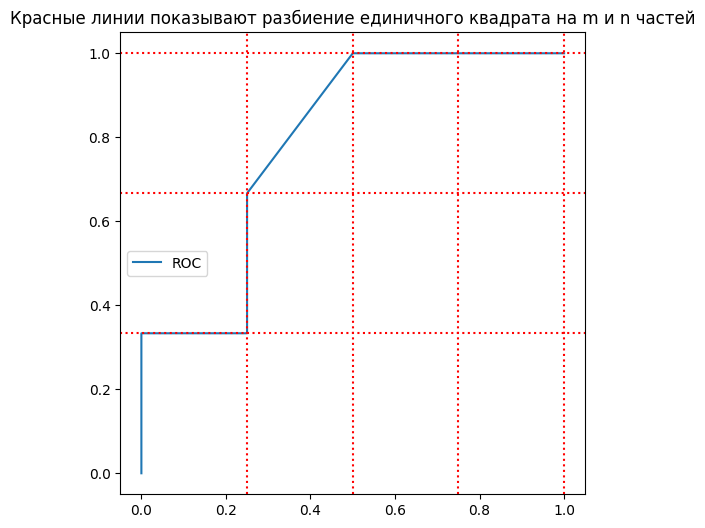

In [45]:
plt.figure(figsize = (6, 6))
plt.plot(fpr, tpr, label = 'ROC')
plt.axvline(0.25, linestyle = 'dotted', c = 'red')
plt.axvline(0.5, linestyle = 'dotted', c = 'red')
plt.axvline(0.75, linestyle = 'dotted', c = 'red')
plt.axvline(1.0, linestyle = 'dotted', c = 'red')
plt.axhline(1/3, linestyle = 'dotted', c = 'red')
plt.axhline(2/3, linestyle = 'dotted', c = 'red')
plt.axhline(1.0, linestyle = 'dotted', c = 'red')
plt.title('Красные линии показывают разбиение единичного квадрата на m и n частей')
plt.legend();

### ROC AUC
Площадь под ROC-кривой равна доле пар наблюдений $(y = 1, y = -1)$, которые алгоритм верно упорядочил, то есть дал объекту класса 1 более высокую оценку, чем объекту класса -1. Пары с одинаковыми оценками идут с весом 1/2. Чем больше ROC AUC, тем качественнее отработал классификатор. Вычислите ROC AUC для обеих построенных ROC-кривых.

Построим ROC-кривую для нашего датасета с вином и рассчитаем площадь под ней

Возьмем модель с подобранным на кросс-валидации `C`

In [46]:
lr = LogisticRegression(C=best_C)
lr.fit(X_train, y_train)

LogisticRegression(C=np.float64(0.06951927961775606))

Выведем график

In [47]:
fpr, tpr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:, 1])

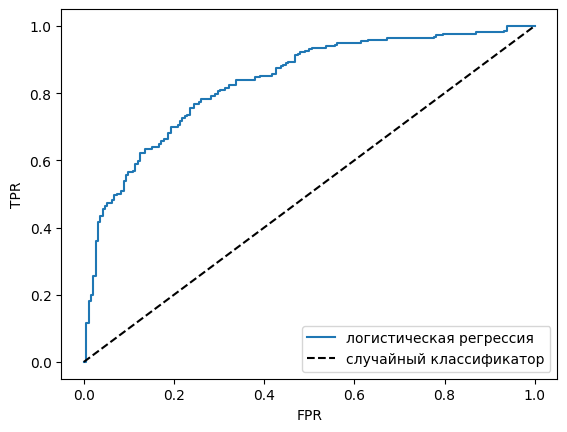

In [48]:
plt.plot(fpr, tpr, label='логистическая регрессия')
plt.plot([0, 1], [0, 1], 'k--', label='случайный классификатор')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend();

**Итог:** кривая заметно выше диагонали, но далеко от левого верхнего угла. Модель лучше случайной, но ошибается часто.

Посчитаем площадь

In [49]:
print(f'Площадь под ROC-кривой составляет {auc(fpr, tpr):.3f}')

Площадь под ROC-кривой составляет 0.834


**Итог:** ROC AUC = 0.834, это близко к результату на кросс-валидации (0.810). Значит, модель не переобучилась и оценке качества можно доверять. Если взять случайное хорошее вино и случайное вино похуже, в 83% случаев модель даст хорошему вину более высокую вероятность.

### Выводы по вину

1. **Классы почти сбалансированы,** поэтому константная модель дает F1 около 0.69. Качество модели нужно сравнивать с этой планкой.
2. **Логистическая регрессия дает F1 = 0.77 и ROC AUC = 0.83:** лучше константы, но далеко от идеала. По физико-химическим признакам качество вина предсказывается лишь частично.
3. **Регуляризация здесь почти ни на что не влияет:** признаков мало, объектов много. Улучшить результат скорее помогут новые признаки или нелинейные модели, чем подбор C.
4. **Метрику для подбора гиперпараметров нужно выбирать осторожно:** F1 зависит от порога и при подборе C тянет к слишком сильной регуляризации, ROC AUC от порога не зависит.